In [1]:
import numpy as np
import pandas as pd

In [2]:
import os

for root, dirs, files in os.walk(r"d:\all files for second term\Summer Training\malaria data set"):
    if "Parasitized" in dirs and "Uninfected" in dirs:
        print("FOUND:", root)

FOUND: d:\all files for second term\Summer Training\malaria data set\cell_images
FOUND: d:\all files for second term\Summer Training\malaria data set\cell_images\cell_images


In [3]:
data_dir = r"d:\all files for second term\Summer Training\malaria data set\cell_images\cell_images"

print(os.listdir(data_dir))

['Parasitized', 'Uninfected']


In [4]:
import os

for class_name in ["Parasitized", "Uninfected"]:
    class_path = os.path.join(data_dir, class_name)
    print(class_name, len(os.listdir(class_path)))

Parasitized 13780
Uninfected 13780


In [5]:
from PIL import Image
import os

for class_name in ["Parasitized", "Uninfected"]:
    class_path = os.path.join(data_dir, class_name)

    sizes = set()
    corrupted = 0

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.add(img.size)
        except:
            corrupted += 1

    print(class_name)
    print("Number of different sizes:", len(sizes))
    print("Some sizes:", list(sizes)[:10])
    print("Corrupted images:", corrupted)

Parasitized
Number of different sizes: 1402
Some sizes: [(166, 181), (130, 115), (88, 118), (139, 163), (199, 214), (205, 145), (97, 166), (163, 148), (121, 151), (94, 133)]
Corrupted images: 1
Uninfected
Number of different sizes: 1207
Some sizes: [(130, 97), (106, 139), (124, 175), (130, 106), (88, 100), (106, 148), (130, 115), (124, 184), (169, 97), (70, 73)]
Corrupted images: 1


In [6]:
from PIL import Image
import os

for class_name in ["Parasitized", "Uninfected"]:
    class_path = os.path.join(data_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except:
            print("Corrupted image:", image_path)
            os.remove(image_path)
            print("Deleted.")

Corrupted image: d:\all files for second term\Summer Training\malaria data set\cell_images\cell_images\Parasitized\Thumbs.db
Deleted.
Corrupted image: d:\all files for second term\Summer Training\malaria data set\cell_images\cell_images\Uninfected\Thumbs.db
Deleted.


In [7]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [8]:
data = []

for class_name in ["Parasitized", "Uninfected"]:
    class_path = os.path.join(data_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        data.append([image_path, class_name])

df = pd.DataFrame(data, columns=["filepath", "label"])

print(df.shape)
print(df["label"].value_counts())

(27558, 2)
label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 22046
Test: 5512


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 17637 validated image filenames belonging to 2 classes.
Found 4409 validated image filenames belonging to 2 classes.
Found 5512 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 146s 259ms/step - accuracy: 0.8614 - loss: 0.3249 - val_accuracy: 0.9360 - val_loss: 0.1782
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 138s 249ms/step - accuracy: 0.9449 - loss: 0.1696 - val_accuracy: 0.9483 - val_loss: 0.1681
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 148s 267ms/step - accuracy: 0.9523 - loss: 0.1474 - val_accuracy: 0.9540 - val_loss: 0.1502
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 141s 255ms/step - accuracy: 0.9603 - loss: 0.1243 - val_accuracy: 0.9508 - val_loss: 0.1473
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 146s 264ms/step - accuracy: 0.9635 - loss: 0.1090 - val_accuracy: 0.9528 - val_loss: 0.1568


In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 135ms/step - accuracy: 0.9521 - loss: 0.1485
Test Loss: 0.14845417439937592
Test Accuracy: 0.9521045088768005


In [16]:
y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype(int).ravel()

y_true = test_generator.classes

173/173 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Parasitized", "Uninfected"]
))

              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      2756
  Uninfected       0.94      0.96      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



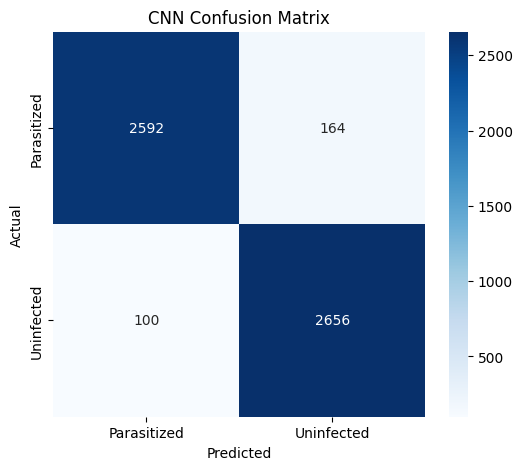

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Parasitized", "Uninfected"],
    yticklabels=["Parasitized", "Uninfected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [19]:
model.save("malaria_cnn_model.keras")

In [20]:
print(os.path.exists("malaria_cnn_model.keras"))

True


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Prediction: Parasitized
Probability: 1.4904359e-05


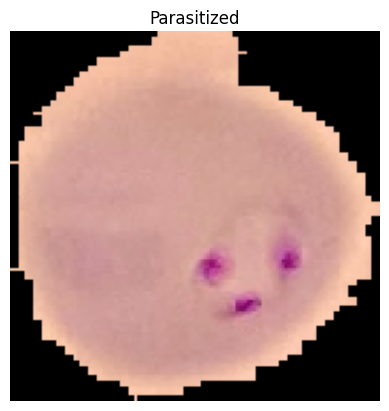

In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"d:\all files for second term\Summer Training\malaria_dataset\cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction >= 0.5:
    result = "Uninfected"
else:
    result = "Parasitized"

print("Prediction:", result)
print("Probability:", prediction)

plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()

In [22]:
print(train_generator.class_indices)

{'Parasitized': 0, 'Uninfected': 1}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction: Uninfected
Probability: 0.98435855


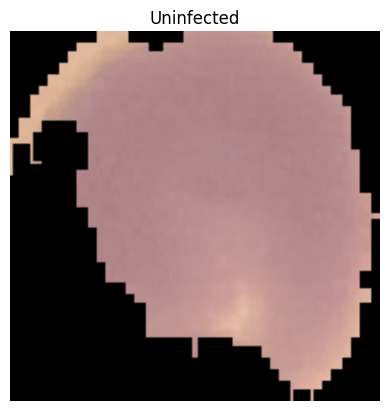

In [23]:
img_path = r"d:\all files for second term\Summer Training\malaria_dataset\cell_images\Uninfected\C1_thinF_IMG_20150604_104919_cell_164.png"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction >= 0.5:
    result = "Uninfected"
else:
    result = "Parasitized"

print("Prediction:", result)
print("Probability:", prediction)

plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()